# Kaggle Digit Recognizer - CNN Ensemble with PyTorch

This notebook implements a high-performance ensemble of CNN models (ResNet and WideConvNet) using PyTorch for the Kaggle Digit Recognizer competition.

 CNN Digit Recognizer
 Copyright (C) 2026  Richard Qin

 This program is free software: you can redistribute it and/or modify
 it under the terms of the GNU General Public License as published by
 the Free Software Foundation, either version 3 of the License, or
 (at your option) any later version.

 This program is distributed in the hope that it will be useful,
 but WITHOUT ANY WARRANTY; without even the implied warranty of
 MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
 GNU General Public License for more details.

 You should have received a copy of the GNU General Public License
 along with this program.  If not, see <https://www.gnu.org/licenses/>.

## 1. Imports and Data Loading

In [1]:
# Load Images
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")



## 2. Data Exploration

Train: (42000, 785)
Test: (28000, 784)
[ 0  7 10 13 15 16 17 20 22 23 25 27 29 54 76 77 80 81 88 89]


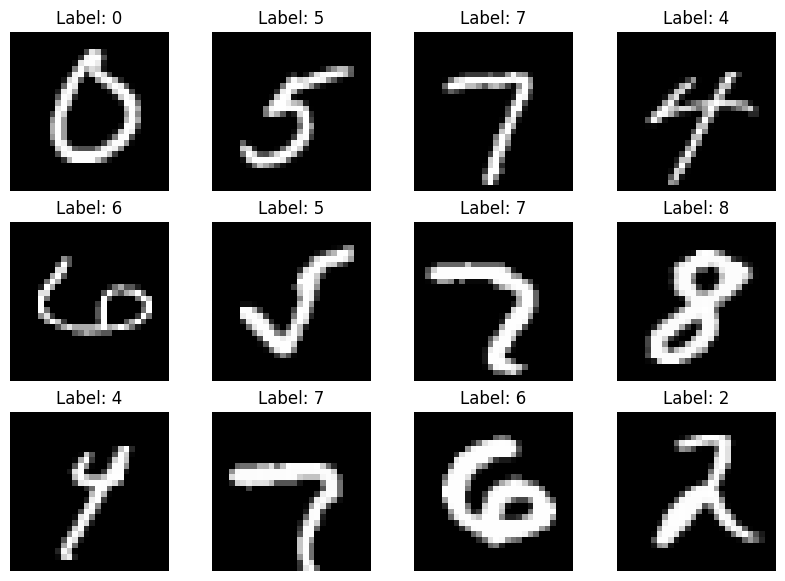

In [2]:
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(np.unique(train_df.iloc[0, 1:].values)[:20])

n = 12
idx = np.random.choice(len(train_df), n, replace=False)

plt.figure(figsize=(10, 7))
for i, id in enumerate(idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(train_df.iloc[id, 1:].values.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {train_df.iloc[id, 0]}")
    plt.axis('off')
# plt.show()



## 3. Preprocessing

(42000, 784)
(42000, 784)
(42000, 1, 28, 28)
(28000, 1, 28, 28)


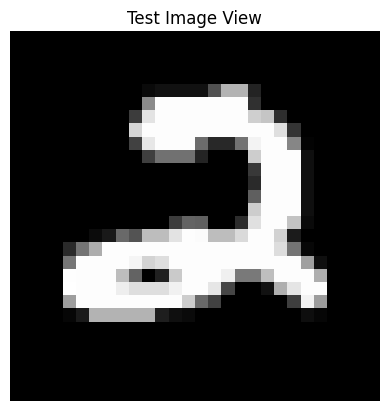

In [3]:
labels = train_df['label'].to_numpy()
train_images=train_df.drop('label',axis=1).to_numpy().astype(np.float32)/255.0

plt.imshow(train_images[0].reshape(28,28), cmap="gray")
plt.title(labels[0])
plt.axis("off")
# plt.show()
print(train_images.shape)

# View of test images
test_images=test_df.to_numpy().astype(np.float32)/255.0
plt.imshow(test_images[0].reshape(28,28), cmap="gray")
plt.title("Test Image View")
plt.axis("off")
# plt.show()

print(train_images.shape)
train_images = train_images.reshape(-1, 1, 28, 28)
test_images = test_images.reshape(-1, 1, 28, 28)
print(train_images.shape)
print(test_images.shape)



## 4. Dataset and Data Augmentation

In [4]:
# Import Modules
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random
from typing import Any
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F


class MNISTDataset(Dataset):
    def __init__(self, images : np.ndarray, labels : np.ndarray = None, transform : transforms.Compose = None) -> None:
        super().__init__()
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long) if labels is not None else None
        self.transform = transform

    def __len__(self) -> int:
        return len(self.images)
    
    def __getitem__(self, index) -> Any:
        img = self.images[index]
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, self.labels[index]
        return img
    
train_transform=transforms.Compose([
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1,0.1),
        scale=(0.9,1.1),
        shear=10
    ),
    transforms.RandomPerspective(distortion_scale=0.2,p=0.5),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.05), value=0)
])



## 5. Verify the Dataset

torch.Size([1, 28, 28]) torch.float32 tensor(1)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

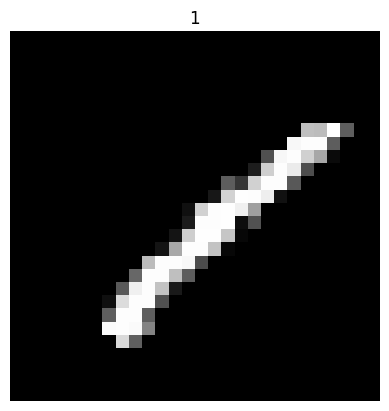

In [5]:
dataset = MNISTDataset(train_images, labels, transform=train_transform)
X, y = dataset[0]
print(X.shape, X.dtype, y)

plt.imshow(X.squeeze(0), cmap="gray")
plt.title(int(y))
plt.axis("off")
# plt.show()




## 6. Model Architectures

In [6]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, max(1, in_channels // reduction), bias=False),
            nn.GELU(),
            nn.Linear(max(1, in_channels // reduction), in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels : int, out_channels : int, stride : int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.GELU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNetMNIST(nn.Module):
    def __init__(self, num_classes : int = 10) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.GELU()
        self.layer1 = self._make_layer(ResidualBlock, 32, 64, 2, stride=1)
        self.layer2 = self._make_layer(ResidualBlock, 64, 128, 2, stride=2)
        self.layer3 = self._make_layer(ResidualBlock, 128, 256, 2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)
    
    def _make_layer(self, block : ResidualBlock, in_channels : int, out_channels : int, num_blocks : int, stride : int) -> nn.Sequential:
        layers : list[ResidualBlock] = []
        layers.append(block(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

class WideConvNet(nn.Module):
    def __init__(self, num_classes : int = 10) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(2, padding=1),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x



## 7. Training and Evaluation Utils

In [7]:
def train_one_epoch(model : nn.Module, dataloader : DataLoader, optimizer : torch.optim.Optimizer, criterion : nn.Module, device : torch.device, scheduler : torch.optim.lr_scheduler._LRScheduler = None) -> tuple[float, float]:
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, targets in dataloader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == targets).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total
            
@torch.no_grad()
def evaluate(model : nn.Module, dataloader : DataLoader, criterion : nn.Module, device : torch.device) -> tuple[float, float]:
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, targets in dataloader:
        imgs, targets = imgs.to(device), targets.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * imgs.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == targets).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total



## 8. K-Fold Training with Ensemble

In [8]:
# K-Fold Training with Ensemble
# 5-fold CV * 2 architectures = 10 models
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# K-Fold Training
M_FOLDS = 5
EPOCHS = 60
BATCH_SIZE = 128
LR = 0.001

models_all = []
skf = StratifiedKFold(n_splits=M_FOLDS, shuffle=True, random_state=SEED)

for model_class, model_name in [(ResNetMNIST, 'ResNet'), (WideConvNet, 'WideConvNet')]:
    print(f'\n{"="*60}')
    print(f'Training {model_name}')
    print(f'{"="*60}')

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_images, labels)):
        print(f'\n--- Fold {fold+1}/{M_FOLDS} ---')

        train_dataset = MNISTDataset(train_images[train_idx], labels[train_idx], transform=train_transform)
        val_dataset = MNISTDataset(train_images[val_idx], labels[val_idx], transform=None)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model = model_class().to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=5e-3, steps_per_epoch=len(train_loader), epochs=EPOCHS)

        best_val_acc = 0.0
        best_state = None
        patience_counter = 0
    
        for epoch in range(EPOCHS):
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
        
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f'  Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
            if patience_counter >= 25:
                print(f'Early stop at epoch {epoch+1}')
                break
    
        model.load_state_dict(best_state)
        model.to(device)
        model.eval()
        models_all.append(model)
        print(f'Best Val Acc: {best_val_acc:.4f}')

print(f'\nTotal models in ensemble: {len(models_all)}')

tta_transforms = [
    None,
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.RandomAffine(degrees=(-5, -5), translate=(0.05, 0.05)),
    transforms.RandomAffine(degrees=0, scale=(0.95, 1.05)),
]

@torch.no_grad()
def predict_ensemble(models : list[nn.Module], images : np.ndarray, device : torch.device, tta_transforms : list[transforms.Compose]) -> np.ndarray:
    all_probs = torch.zeros(len(images), 10)

    for model in models:
        model.eval()
        for tta_tf in tta_transforms:
            ds = MNISTDataset(images, labels=None, transform=tta_tf)
            loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
            probs_list = []
            for imgs in loader:
                imgs = imgs.to(device)
                logits = model(imgs)
                probs_list.append(F.softmax(logits, dim=1).cpu())
            all_probs += torch.cat(probs_list, dim=0)

    predictions = all_probs.argmax(dim=1).numpy()
    return predictions

predictions = predict_ensemble(models_all, test_images, device, tta_transforms)
print(f'Predictions shape: {predictions.shape}')
print(f'Prediction distribution: {np.bincount(predictions)}')


Device: cuda

Training ResNet

--- Fold 1/5 ---
  Epoch 01 | Train Loss: 0.9205 Acc: 0.8568 | Val Loss: 0.6089 Acc: 0.9705
  Epoch 05 | Train Loss: 0.5659 Acc: 0.9814 | Val Loss: 0.5307 Acc: 0.9908
  Epoch 10 | Train Loss: 0.5469 Acc: 0.9860 | Val Loss: 0.5311 Acc: 0.9889
  Epoch 15 | Train Loss: 0.5391 Acc: 0.9871 | Val Loss: 0.5269 Acc: 0.9907
  Epoch 20 | Train Loss: 0.5330 Acc: 0.9897 | Val Loss: 0.5179 Acc: 0.9936
  Epoch 25 | Train Loss: 0.5267 Acc: 0.9922 | Val Loss: 0.5199 Acc: 0.9924
  Epoch 30 | Train Loss: 0.5259 Acc: 0.9929 | Val Loss: 0.5184 Acc: 0.9932
  Epoch 35 | Train Loss: 0.5234 Acc: 0.9934 | Val Loss: 0.5154 Acc: 0.9950
  Epoch 40 | Train Loss: 0.5184 Acc: 0.9949 | Val Loss: 0.5143 Acc: 0.9945
  Epoch 45 | Train Loss: 0.5154 Acc: 0.9961 | Val Loss: 0.5113 Acc: 0.9963
  Epoch 50 | Train Loss: 0.5119 Acc: 0.9974 | Val Loss: 0.5115 Acc: 0.9954
  Epoch 55 | Train Loss: 0.5108 Acc: 0.9979 | Val Loss: 0.5117 Acc: 0.9960
  Epoch 60 | Train Loss: 0.5088 Acc: 0.9987 | Val Lo

## 9. Inference and Submission

In [9]:
submission = pd.DataFrame({
    'ImageId': range(1, len(predictions) + 1),
    'Label': predictions
})
submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {submission.shape}')
print(submission.head(10))

Submission saved: (28000, 2)
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3


The Final Score on kaggle is 0.99728.